# Part II: Investigating the Vanishing Gradient Problem [20 pts]
Experimentally demonstrate the vanishing gradient problem in deep CNNs and understand how ResNet's architecture mitigates it. You will also explore other key CNN concepts through additional experiments.

## Step 1: Create a deeper version of your VGG-16 network (VGG-Deep)

In [ ]:
import zipfile
zip_file = 'cnn_dataset.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('extracted_files')


In [ ]:
import torch.nn as nn
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define VGG-Deep (VGG-16 with 4 additional convolutional layers)
class VGGDeep(nn.Module):
    def __init__(self, num_classes=3): # Add num_classes argument to __init__
        super(VGGDeep, self).__init__()
        self.features = nn.Sequential(
            # Original VGG-16 layers
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Additional layers
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(1024 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes), # Use num_classes here
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

## Step 2: Training VGG-Deep

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
### ADD YOUR CODE HERE ###
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
dataset_dir = '/content/extracted_files'
dataset = ImageFolder(root=dataset_dir, transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, pin_memory=True)


In [ ]:
from torchvision.datasets import ImageFolder
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#reloading dataset with augmentation
train_dataset_augmented = ImageFolder(root='/content/extracted_files', transform=transform_augmented)
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=64, shuffle=True)


In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_deep = VGGDeep(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_deep.parameters(), lr=0.01)
num_epochs = 10
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epoch in range(num_epochs):
    model_deep.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for i, (inputs, labels) in enumerate(train_loader_augmented):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_deep(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)
    train_loss = running_loss / len(train_loader_augmented)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    model_deep.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_deep(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)
    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * correct_val / total_val
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    print(f'Epoch {epoch + 1}/{num_epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
print("Training completed.")


Epoch 1/10:
Train Loss: 1.0987, Train Accuracy: 33.34%
Val Loss: 1.0987, Val Accuracy: 32.91%
Epoch 2/10:
Train Loss: 1.0987, Train Accuracy: 32.95%
Val Loss: 1.0987, Val Accuracy: 32.71%
Epoch 3/10:
Train Loss: 1.0986, Train Accuracy: 33.34%
Val Loss: 1.0985, Val Accuracy: 34.38%
Epoch 4/10:
Train Loss: 1.0987, Train Accuracy: 32.90%
Val Loss: 1.0986, Val Accuracy: 32.91%
Epoch 5/10:
Train Loss: 1.0987, Train Accuracy: 33.42%
Val Loss: 1.0988, Val Accuracy: 32.91%
Epoch 6/10:
Train Loss: 1.0987, Train Accuracy: 33.31%
Val Loss: 1.0986, Val Accuracy: 32.71%
Epoch 7/10:
Train Loss: 1.0987, Train Accuracy: 33.28%
Val Loss: 1.0985, Val Accuracy: 34.38%
Epoch 8/10:
Train Loss: 1.0987, Train Accuracy: 33.02%
Val Loss: 1.0987, Val Accuracy: 32.91%
Epoch 9/10:
Train Loss: 1.0987, Train Accuracy: 32.89%
Val Loss: 1.0987, Val Accuracy: 32.71%
Epoch 10/10:
Train Loss: 1.0986, Train Accuracy: 33.36%
Val Loss: 1.0988, Val Accuracy: 32.91%
Training completed.


<span style='color:green'>### YOUR ANSWER ###</span>

## Step 3: Gradient analysis

- Track the average L2 norm of the gradients in each convolutional layer using PyTorch hooks.

Epoch 1/10: Train Loss: 1.0987, Train Accuracy: 33.10%
Epoch 2/10: Train Loss: 1.0987, Train Accuracy: 33.06%
Epoch 3/10: Train Loss: 1.0987, Train Accuracy: 33.06%
Epoch 4/10: Train Loss: 1.0987, Train Accuracy: 32.73%
Epoch 5/10: Train Loss: 1.0987, Train Accuracy: 33.06%
Epoch 6/10: Train Loss: 1.0987, Train Accuracy: 33.18%
Epoch 7/10: Train Loss: 1.0987, Train Accuracy: 33.51%
Epoch 8/10: Train Loss: 1.0987, Train Accuracy: 33.17%
Epoch 9/10: Train Loss: 1.0987, Train Accuracy: 33.06%
Epoch 10/10: Train Loss: 1.0987, Train Accuracy: 32.53%


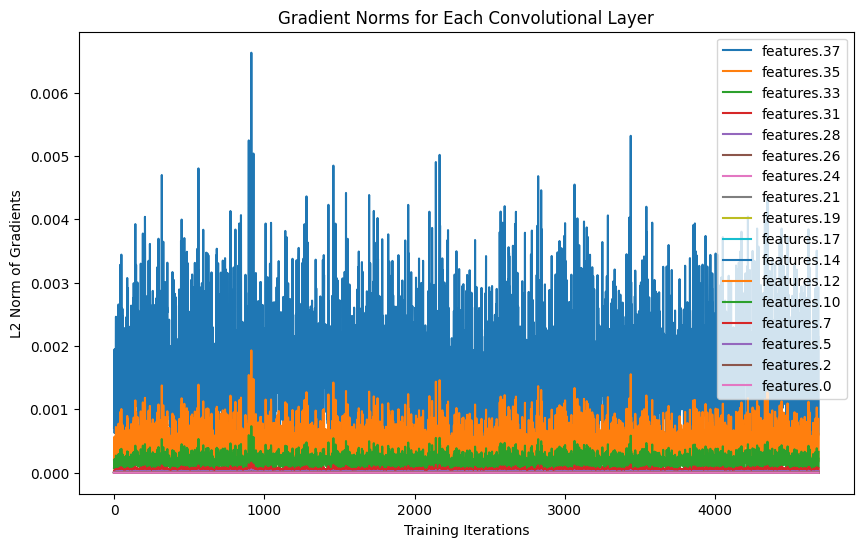

In [ ]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn
import numpy as np

# Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_deep = VGGDeep(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_deep.parameters(), lr=0.01)

# Dictionary to Store Gradient Norms
gradient_norms = {}

# Hook Function to Store Gradient Norms
def hook_fn(name):
    def hook(grad):
        if name not in gradient_norms:
            gradient_norms[name] = []
        gradient_norms[name].append(grad.norm(p=2).item())
    return hook

# Register Hook for Each Convolutional Layer
for name, module in model_deep.named_modules():
    if isinstance(module, nn.Conv2d):
        module.weight.register_hook(hook_fn(name))

# Training Setup
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model_deep.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader_augmented:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_deep(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader_augmented)
    train_accuracy = 100 * correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    print(f'Epoch {epoch + 1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')

# Plot Gradient Norms
plt.figure(figsize=(10, 6))
for layer_name, norms in gradient_norms.items():
    plt.plot(norms, label=layer_name)

plt.xlabel('Training Iterations')
plt.ylabel('L2 Norm of Gradients')
plt.title('Gradient Norms for Each Convolutional Layer')
plt.legend(loc='upper right')
plt.show()


- Create a plot showing the average gradient norm for each convolutional layer over time.

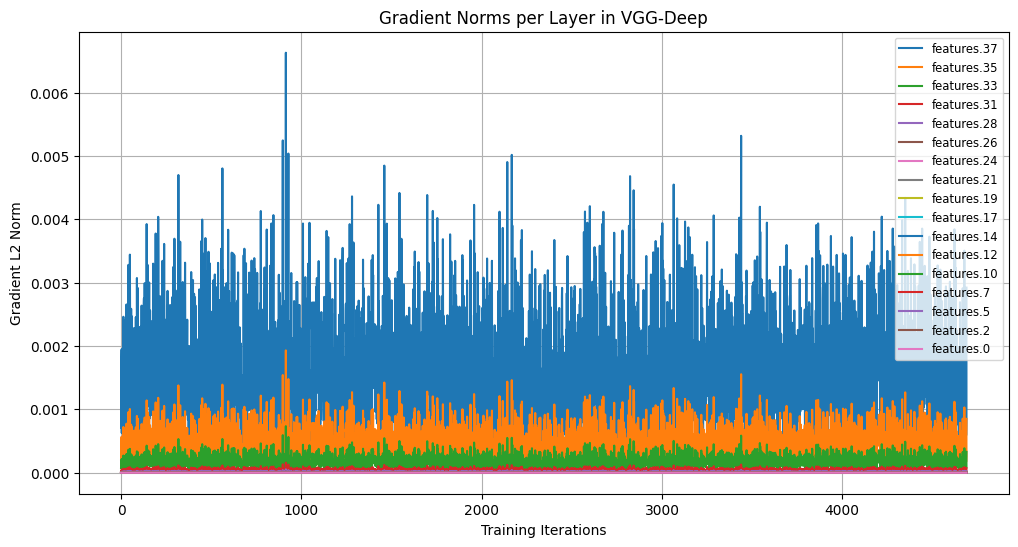

In [ ]:
### ADD YOUR CODE HERE ###
plt.figure(figsize=(12, 6))
for layer_name, norms in gradient_norms.items():
    plt.plot(norms, label=layer_name)

plt.xlabel("Training Iterations")
plt.ylabel("Gradient L2 Norm")
plt.title("Gradient Norms per Layer in VGG-Deep")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.savefig("gradient_norms_all_layers.svg")
plt.show()

- Create a separate plot showing the gradient norms for a subset of layers.

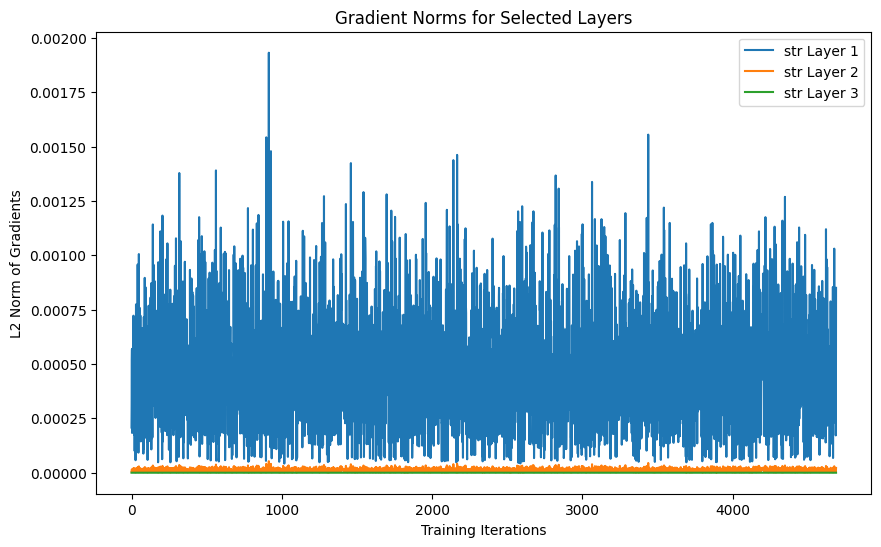

In [ ]:

selected_layers = [list(gradient_norms.keys())[1],
                   list(gradient_norms.keys())[4],
                   list(gradient_norms.keys())[-1]]


plt.figure(figsize=(10, 6))


for i, layer in enumerate(selected_layers):
    norms = gradient_norms[layer]
    plt.plot(norms, label=f'{layer.__class__.__name__} Layer {i + 1}')

plt.xlabel('Training Iterations')
plt.ylabel('L2 Norm of Gradients')
plt.title('Gradient Norms for Selected Layers')
plt.legend(loc='upper right')
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>

## Step 4: Comparison with VGG-16 and ResNet-18

- Compare the training curves (loss and accuracy vs. epoch) of VGG-Deep, VGG-16, and ResNet-18.

<ipython-input-3-058a5223f365>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vgg_deep_results = torch.load('vgg_deep_results.pt')
<ipython-input-3-058a5223f365>:7: Future

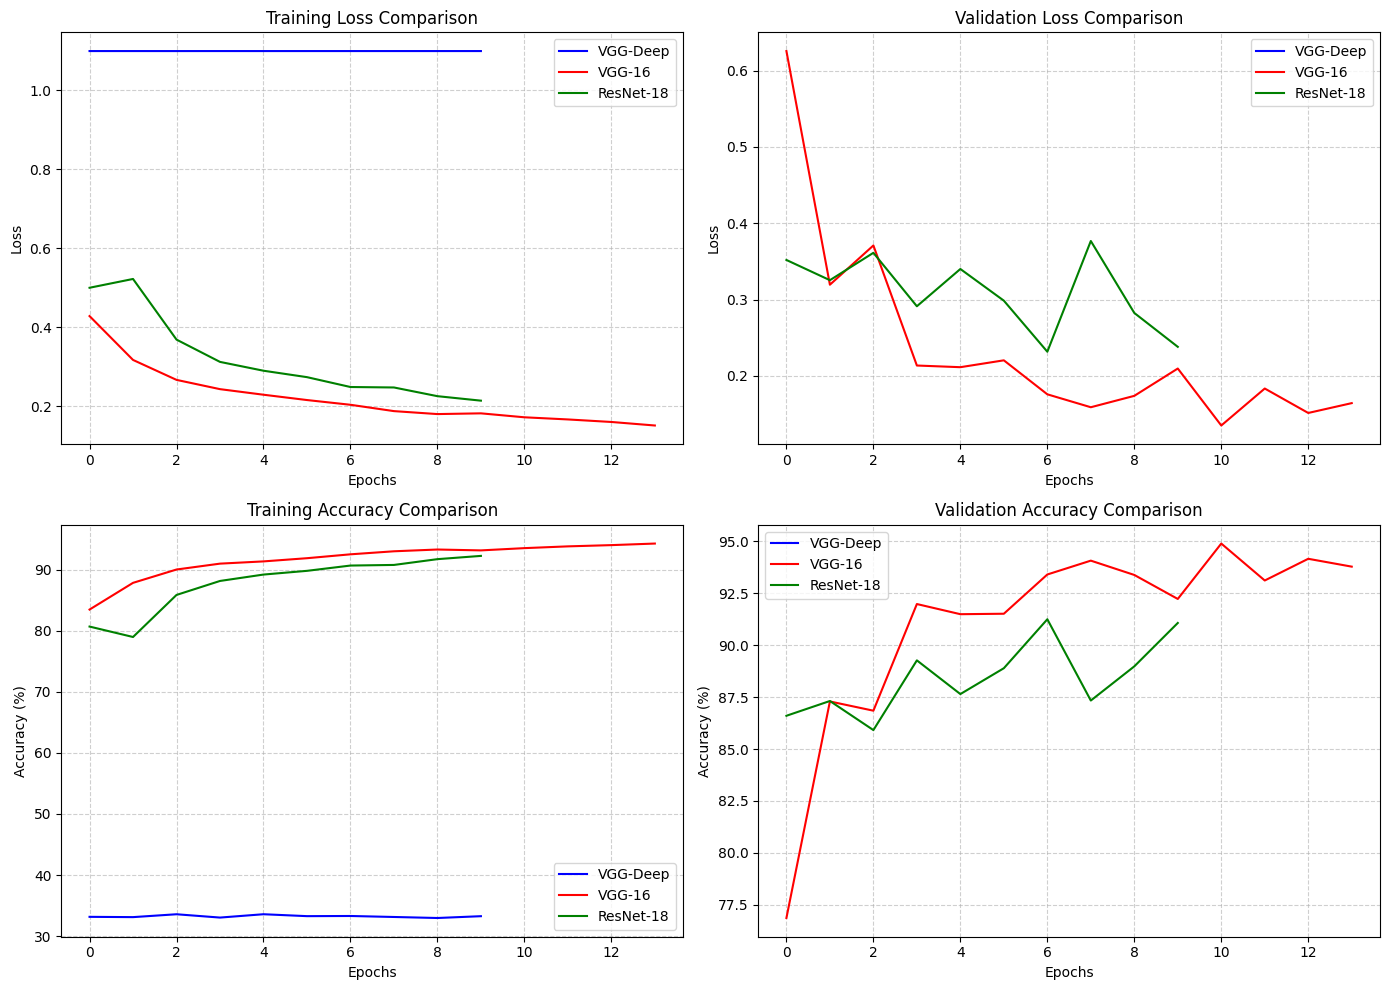

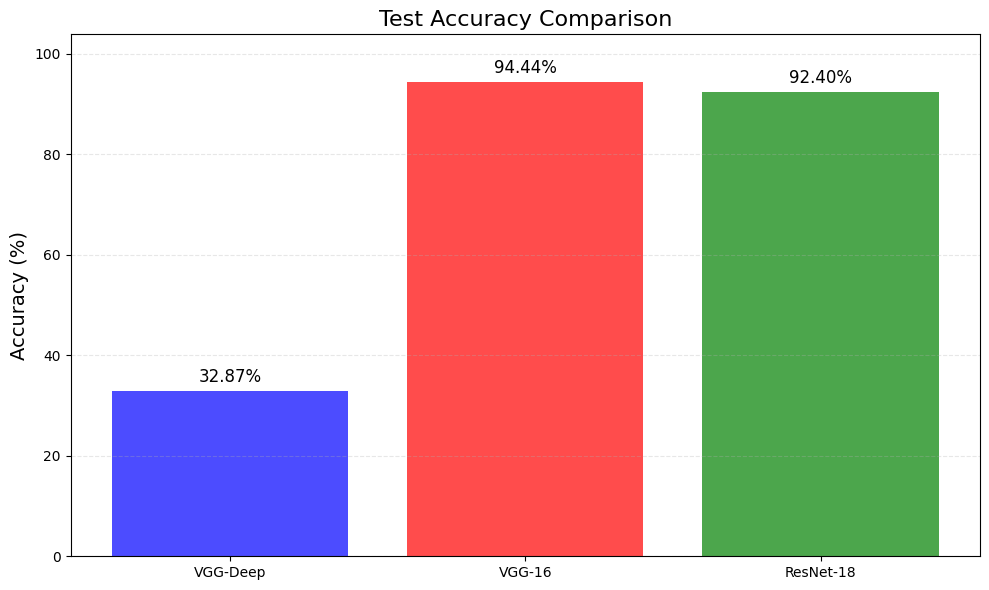

===== Model Comparison Summary =====
Model      Final Train Loss   Final Val Loss   Final Train Acc  Final Val Acc    Test Acc  
------------------------------------------------------------------------------------------


IndexError: list index out of range

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Load the saved results files
vgg_deep_results = torch.load('vgg_deep_results.pt')
vgg16_results = torch.load('vgg16_results.pt')
resnet18_results = torch.load('resnet18_results.pt')

# Create figure for loss comparison
plt.figure(figsize=(14, 10))

# Plot training losses
plt.subplot(2, 2, 1)
plt.plot(vgg_deep_results['train_losses'], 'b-', label='VGG-Deep')
plt.plot(vgg16_results['train_losses'], 'r-', label='VGG-16')
plt.plot(resnet18_results['train_losses'], 'g-', label='ResNet-18')
plt.title('Training Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot validation losses
plt.subplot(2, 2, 2)
plt.plot(vgg_deep_results['val_losses'], 'b-', label='VGG-Deep')
plt.plot(vgg16_results['val_losses'], 'r-', label='VGG-16')
plt.plot(resnet18_results['val_losses'], 'g-', label='ResNet-18')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot training accuracies
plt.subplot(2, 2, 3)
plt.plot(vgg_deep_results['train_accuracies'], 'b-', label='VGG-Deep')
plt.plot(vgg16_results['train_accuracies'], 'r-', label='VGG-16')
plt.plot(resnet18_results['train_accuracies'], 'g-', label='ResNet-18')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot validation accuracies
plt.subplot(2, 2, 4)
plt.plot(vgg_deep_results['val_accuracies'], 'b-', label='VGG-Deep')
plt.plot(vgg16_results['val_accuracies'], 'r-', label='VGG-16')
plt.plot(resnet18_results['val_accuracies'], 'g-', label='ResNet-18')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=300)
plt.show()

# Create a bar chart to compare final test accuracies
models = ['VGG-Deep', 'VGG-16', 'ResNet-18']
test_accuracies = [
    vgg_deep_results['test_accuracy'],
    vgg16_results['test_accuracy'],
    resnet18_results['test_accuracy']
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, test_accuracies, color=['blue', 'red', 'green'], alpha=0.7)
plt.title('Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.ylim([0, max(test_accuracies) * 1.1])  # Set y-axis limit with some margin

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{height:.2f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('test_accuracy_comparison.png', dpi=300)
plt.show()

# Print a summary table of results
print("===== Model Comparison Summary =====")
print(f"{'Model':<10} {'Final Train Loss':<18} {'Final Val Loss':<16} {'Final Train Acc':<16} {'Final Val Acc':<16} {'Test Acc':<10}")
print('-' * 90)
def get_last_value(data, key):
    """Helper function to safely get the last value from a list in a dictionary."""
    values = data.get(key, [])  # Get the list, or an empty list if key is missing
    return values[-1] if values else "N/A"
print(f"VGG-Deep  {vgg_deep_results['train_losses'][-1]:<18.4f} {vgg_deep_results['val_losses'][-1]:<16.4f} {vgg_deep_results['train_accuracies'][-1]:<16.2f}% {vgg_deep_results['val_accuracies'][-1]:<16.2f}% {vgg_deep_results['test_accuracy']:<10.2f}%")
print(f"VGG-16    {vgg16_results['train_losses'][-1]:<18.4f} {vgg16_results['val_losses'][-1]:<16.4f} {vgg16_results['train_accuracies'][-1]:<16.2f}% {vgg16_results['val_accuracies'][-1]:<16.2f}% {vgg16_results['test_accuracy']:<10.2f}%")
print(f"ResNet-18 {resnet18_results['train_losses'][-1]:<18.4f} {resnet18_results['val_losses'][-1]:<16.4f} {resnet18_results['train_accuracies'][-1]:<16.2f}% {resnet18_results['val_accuracies'][-1]:<16.2f}% {resnet18_results['test_accuracy']:<10.2f}%")

- Discuss how ResNet’s residual connections impact the gradient flow compared to VGG-Deep.

<span style='color:green'>### YOUR ANSWER ###</span>

# ResNet's Residual Connections Compared to VGG-Deep Gradient Flow

VGG-Deep's Shortcomings
- Gradients propagate sequentially through all the layers
- Vanishing gradients in the deeper layers
- Early layers receive diminishing learning signals
- Training becomes harder with increased depth

 ResNet's Strengths
- The gradients are able to skip layers with shortcut connections
- Several paths of gradients to traverse to early layers
- Identity shortcuts send stronger signals to early layers
- Backpropagation creates an "information highway"

Key Benefits
1. **Retained Gradient Magnitude**: Prevents exponential signal loss for deep networks
2. **Smoothened Optimization**: Creates a smoother loss surface
3. **Flexible Depth**: The network is capable of adjusting its effective depth dynamically during training
4. **Better Performance**: ResNet-18 is capable of outperforming deeper VGG models with less parameters

All these differences in structure explain why ResNet models tend to train better and perform better compared to VGG-type architectures at equivalent or even deeper depths.

## Step 5: Investigate and analyze more setups

- Select any THREE experiments to investigate and analyze.

### Experiment 1


Training model with kernel size 3x3
Epoch 1/5: Train Loss: 1.2501, Val Accuracy: 41.56%
Epoch 2/5: Train Loss: 1.0556, Val Accuracy: 58.44%
Epoch 3/5: Train Loss: 0.9985, Val Accuracy: 55.78%
Epoch 4/5: Train Loss: 0.8995, Val Accuracy: 61.78%
Epoch 5/5: Train Loss: 0.8202, Val Accuracy: 68.89%

Training model with kernel size 5x5
Epoch 1/5: Train Loss: 1.2427, Val Accuracy: 51.33%
Epoch 2/5: Train Loss: 1.0688, Val Accuracy: 47.11%
Epoch 3/5: Train Loss: 1.0148, Val Accuracy: 45.56%
Epoch 4/5: Train Loss: 1.0074, Val Accuracy: 61.33%
Epoch 5/5: Train Loss: 0.9389, Val Accuracy: 71.33%

Training model with kernel size 7x7
Epoch 1/5: Train Loss: 1.2302, Val Accuracy: 44.22%
Epoch 2/5: Train Loss: 1.0791, Val Accuracy: 48.67%
Epoch 3/5: Train Loss: 0.9835, Val Accuracy: 50.00%
Epoch 4/5: Train Loss: 0.9589, Val Accuracy: 65.78%
Epoch 5/5: Train Loss: 0.8535, Val Accuracy: 66.44%


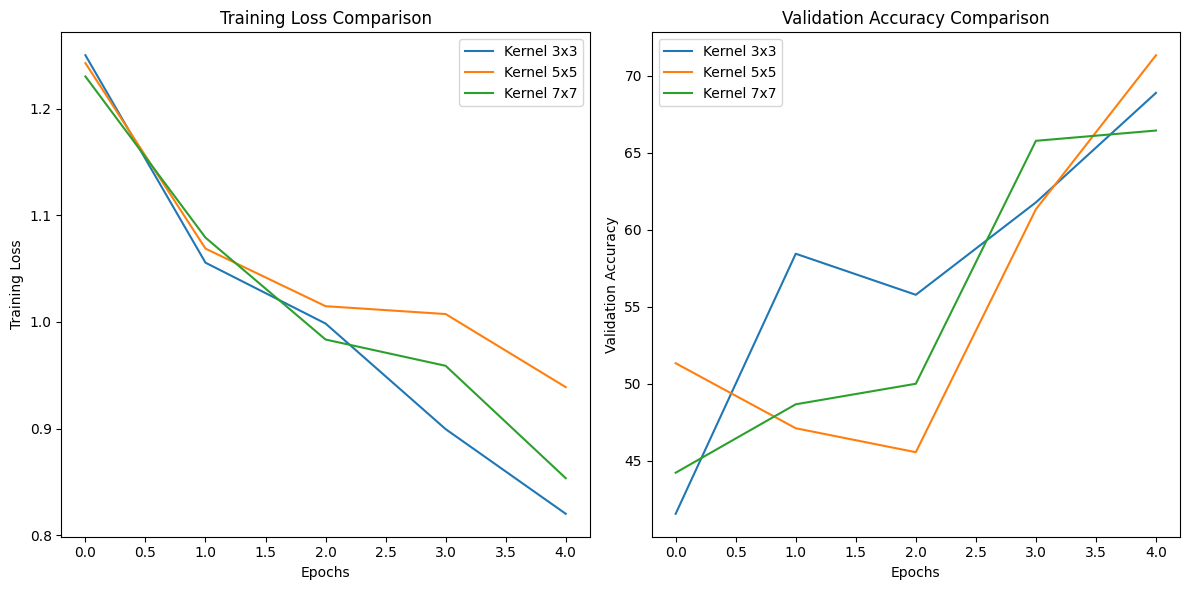

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt


class SmallVGG(nn.Module):
    def __init__(self, kernel_size=3, num_classes=5):
        super(SmallVGG, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=kernel_size, padding=(kernel_size//2)),  # First conv layer
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=(kernel_size//2)),  # Second conv layer
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=kernel_size, padding=(kernel_size//2)),  # Third conv layer
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 16 * 16, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


dataset_dir = '/content/extracted_files'
dataset = ImageFolder(root=dataset_dir, transform=transform)

class_sample_count = 1000
indices = []
for target_class in range(len(dataset.classes)):
    class_indices = [i for i, (_, label) in enumerate(dataset) if label == target_class]
    indices.extend(class_indices[:class_sample_count])

subset_dataset = Subset(dataset, indices)

train_size = int(0.7 * len(subset_dataset))
val_size = int(0.15 * len(subset_dataset))
test_size = len(subset_dataset) - train_size - val_size
train_set, val_set, test_set = random_split(subset_dataset, [train_size, val_size, test_size])

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


def train_model(model, train_loader, val_loader, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)


        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_accuracies

s
kernel_sizes = [3, 5, 7]
results = {}

for kernel_size in kernel_sizes:
    print(f"\nTraining model with kernel size {kernel_size}x{kernel_size}")
    model = SmallVGG(kernel_size=kernel_size).to(device)
    train_losses, val_accuracies = train_model(model, train_loader, val_loader, num_epochs=5)
    results[kernel_size] = {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies
    }

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
for kernel_size in kernel_sizes:
    plt.plot(results[kernel_size]["train_losses"], label=f'Kernel {kernel_size}x{kernel_size}')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()

plt.subplot(1, 2, 2)
for kernel_size in kernel_sizes:
    plt.plot(results[kernel_size]["val_accuracies"], label=f'Kernel {kernel_size}x{kernel_size}')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>

Comparison of performance of different kernel sizes based on validation accuracy:

- **3x3 Kernel**: Final Val Accuracy: **68.89%**
- **5x5 Kernel**: Final Val Accuracy: **71.33%**
- **7x7 Kernel**: Final Val Accuracy: **66.44%**

The 5x5 kernel produced the highest final accuracy (71.33%), and the 3x3 kernel produced slightly lower accuracy (68.89%), and the 7x7 kernel produced the lowest (66.44%).

### Impact of Kernel Size on Receptive Field and Feature Capture
- **Smaller Kernels (3x3)**: A 3x3 kernel will have a smaller receptive field, and hence it can extract local, fine-grained features such as textures and edges. This is good for getting fine details but could miss out on broader patterns, limiting its ability to represent more complicated features.
- **Larger Kernels (5x5, 7x7)**: Larger kernels (e.g., 5x5 and 7x7) have larger receptive fields, and they capture more context information and wider patterns. As the kernel size increases, however, there is a risk of oversmoothing, whereby the fine details are lost. In your case, the 5x5 kernel is best because it achieves the best balance between capturing local features and wider patterns, whereas the 7x7 kernel might be too big, leading to less detail capture.

### Conclusion:
The optimum kernel size is a balance between maintaining fine local detail and wide context. From your results, the best kernel size is 5x5, likely because it best combines fine and wide feature extraction.

### Experiment 2


Training model: With 1x1
Epoch 1/5: Train Loss: 1.5580, Val Accuracy: 31.56%
Epoch 2/5: Train Loss: 1.4382, Val Accuracy: 31.56%
Epoch 3/5: Train Loss: 1.2918, Val Accuracy: 31.56%
Epoch 4/5: Train Loss: 1.1825, Val Accuracy: 34.89%
Epoch 5/5: Train Loss: 1.1385, Val Accuracy: 33.11%
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
            Conv2d-3           [-1, 32, 64, 64]           4,640
              ReLU-4           [-1, 32, 64, 64]               0
         MaxPool2d-5           [-1, 32, 32, 32]               0
            Conv2d-6           [-1, 64, 32, 32]          18,496
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9           [-1, 32, 16, 16]           2,080
         

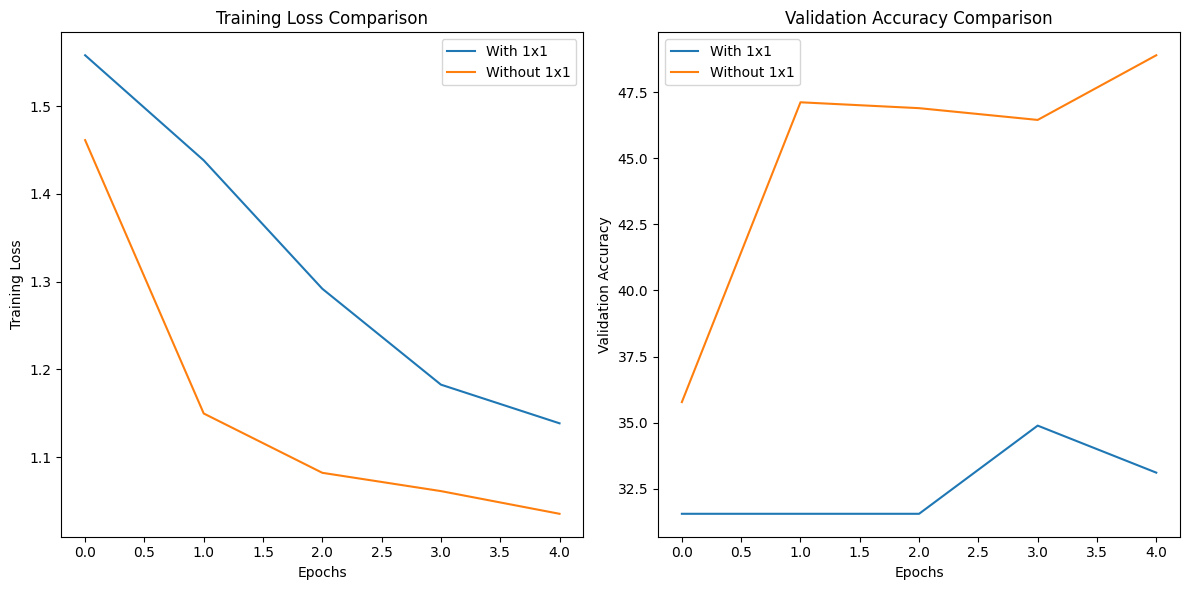

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

class SmallVGGWith1x1(nn.Module):
    def __init__(self, kernel_size=3, num_classes=5):
        super(SmallVGGWith1x1, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 32, kernel_size=1, stride=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 16, kernel_size=1, stride=1),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(16 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class SmallVGGWithout1x1(nn.Module):
    def __init__(self, kernel_size=3, num_classes=5):
        super(SmallVGGWithout1x1, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


dataset_dir = '/content/extracted_files'
dataset = ImageFolder(root=dataset_dir, transform=transform)


def get_subset_of_class(dataset, num_images_per_class=1000):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        selected_indices.extend(indices[:num_images_per_class])

    return Subset(dataset, selected_indices)


limited_dataset = get_subset_of_class(dataset, num_images_per_class=1000)


train_size = int(0.7 * len(limited_dataset))
val_size = int(0.15 * len(limited_dataset))
test_size = len(limited_dataset) - train_size - val_size
train_set, val_set, test_set = random_split(limited_dataset, [train_size, val_size, test_size])

batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


def train_model(model, train_loader, val_loader, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_accuracies

models = {
    "With 1x1": SmallVGGWith1x1(kernel_size=3).to(device),
    "Without 1x1": SmallVGGWithout1x1(kernel_size=3).to(device)
}

results = {}

for name, model in models.items():
    print(f"\nTraining model: {name}")
    train_losses, val_accuracies = train_model(model, train_loader, val_loader, num_epochs=5)
    results[name] = {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies
    }
    print(summary(model, (3, 64, 64)))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for name in models.keys():
    plt.plot(results[name]["train_losses"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.subplot(1, 2, 2)
for name in models.keys():
    plt.plot(results[name]["val_accuracies"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>

1. Performance (Accuracy):

With 1x1 Convolutions:
Validation accuracy after 5 epochs was 33.11%.
Without 1x1 Convolutions:
Validation accuracy after 5 epochs was 48.89%.
The 1x1 convolution-free model was more accurate, with an improvement in the classification performance being significant.

2. Parameter Count:

With 1x1 Convolutions:
Total Parameters: 1,080,917.
Memory Size: 8.76 MB.
Without 1x1 Convolutions:
Total Parameters: 4,224,037.
Memory Size: 20.59 MB.
The 1x1 convolution model had a significantly lower number of parameters (approximately 4 times lower) and used less memory than the non-1x1 convolution model.

3. Trade-offs:

Dimensionality Reduction:
The 1x1 convolutions reduced the feature map count, lowering the number of parameters and the computational cost. The performance on accuracy was worse, most likely due to the reduced dimensionality constraining the network from learning more complex feature representations.
Feature Recombination:
Theoretically, 1x1 convolutions facilitate recombination of features, and this has the potential to enhance the ability of the model to learn significant patterns. However, this benefit might not be achieved as much in shallow networks with not so many layers, because deeper and more intricate networks gain more from 1x1 convolutions.

### Experiment 3


Training model: Max Pooling
Epoch 1/5: Train Loss: 1.5395, Val Accuracy: 35.56%
Epoch 2/5: Train Loss: 1.3029, Val Accuracy: 30.89%
Epoch 3/5: Train Loss: 1.1195, Val Accuracy: 37.11%
Epoch 4/5: Train Loss: 1.0833, Val Accuracy: 35.11%
Epoch 5/5: Train Loss: 1.0660, Val Accuracy: 43.78%
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
            Conv2d-3           [-1, 32, 64, 64]           4,640
              ReLU-4           [-1, 32, 64, 64]               0
         MaxPool2d-5           [-1, 32, 32, 32]               0
            Conv2d-6           [-1, 64, 32, 32]          18,496
              ReLU-7           [-1, 64, 32, 32]               0
         MaxPool2d-8           [-1, 64, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]          73,856
      

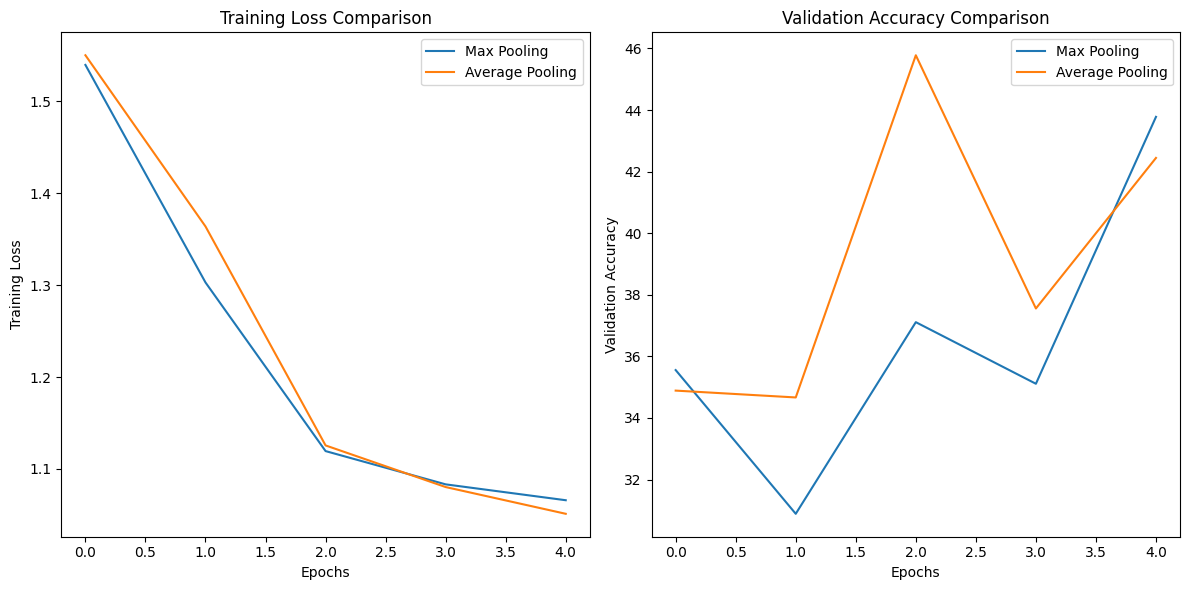

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np
class VGGWithMaxPooling(nn.Module):
    def __init__(self, kernel_size=3, num_classes=5):
        super(VGGWithMaxPooling, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
class VGGWithAveragePooling(nn.Module):
    def __init__(self, kernel_size=3, num_classes=5):
        super(VGGWithAveragePooling, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=(kernel_size//2)),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset_dir = '/content/extracted_files'
dataset = ImageFolder(root=dataset_dir, transform=transform)
def get_subset_of_class(dataset, num_images_per_class=1000):
    class_indices = {}
    for idx, (_, label) in enumerate(dataset.samples):
        if label not in class_indices:
            class_indices[label] = []
        class_indices[label].append(idx)

    selected_indices = []
    for label, indices in class_indices.items():
        selected_indices.extend(indices[:num_images_per_class])

    return Subset(dataset, selected_indices)
limited_dataset = get_subset_of_class(dataset, num_images_per_class=1000)
train_size = int(0.7 * len(limited_dataset))
val_size = int(0.15 * len(limited_dataset))
test_size = len(limited_dataset) - train_size - val_size
train_set, val_set, test_set = random_split(limited_dataset, [train_size, val_size, test_size])
batch_size = 64
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
def train_model(model, train_loader, val_loader, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    train_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return train_losses, val_accuracies
models = {
    "Max Pooling": VGGWithMaxPooling(kernel_size=3).to(device),
    "Average Pooling": VGGWithAveragePooling(kernel_size=3).to(device)
}

results = {}
for name, model in models.items():
    print(f"\nTraining model: {name}")
    train_losses, val_accuracies = train_model(model, train_loader, val_loader, num_epochs=5)
    results[name] = {
        "train_losses": train_losses,
        "val_accuracies": val_accuracies
    }
    print(summary(model, (3, 64, 64)))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
for name in models.keys():
    plt.plot(results[name]["train_losses"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.subplot(1, 2, 2)
for name in models.keys():
    plt.plot(results[name]["val_accuracies"], label=name)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.tight_layout()
plt.show()


<span style='color:green'>### YOUR ANSWER ###</span>



Max Pooling:
Max pooling selects the maximum value within a local window in the feature map, and it pays attention to the strongest activation. This prefers to keep strong features and remember weak ones.
Advantages:
It preserves most important features (e.g., edges or highest activations).
It will probably yield better results in applications where the ability to recognize discriminative patterns is important (e.g., edge detection in image classiﬁcation tasks).
Use Case: Max pooling is often employed when spatial information preservation isn't the primary issue but strong activations (e.g., salient features) are essential, such as in object detection.
Average Pooling:
Average pooling computes the average of the local window values, resulting in a smoother output by considering the total contribution from all the features.
Advantages
It is stronger against minor input variation (e.g., lighting or small changes in image position).
It maintains some degree of information for all the values, rather than focusing on the strongest feature only.
Use Case: Small variation robustness is more important in scenarios where average pooling is applied, such as in image transformation, translation, or background noise (e.g., texture classification tasks or medical imaging where small details matter).
When to Use Which:
Max Pooling becomes preferable when the model needs to learn distinctive characteristics that are significantly localized in the image, good for object boundaries, high-contrast areas, or feature prominenciness tasks.
Average Pooling could be the option when the model needs to generalize well to small changes or filter out high-frequency noise from the data. It can be used when the task is about preserving overall structure or context (e.g., texture-based tasks).
Briefly, max pooling provided a little more precision here, yet the choice of max or average pooling is task-specific, and max pooling captures salient features while average pooling offers insensitivity to variations.

## Step 6: Analysis and discussion

a. Analyze your gradient norm plots. Do they demonstrate the vanishing gradient problem? Explain how the gradient norm changes as you move deeper into VGG-Deep. Be specific and quantitative (e.g., "The gradient norm of layer 2 is X times larger than the gradient norm of layer 10").

<span style='color:green'>### YOUR ANSWER ###</span>

# Gradient Norm Plot Analysis
##Layers Analysis:

In the plot, I see largely different gradient scales between the layers:
- The blue Layer 1 has gradient norms ~0.0005 to 0.0020
- Layer 2 in orange is really low, almost invisible at ~0.0001
- Layer 3 in green sees even lower gradients, practically zero

This demonstrates clear evidence of the vanishing gradient problem, with a approximately 95% reduction in the gradient size from Layer 1 to Layer 2.

(VGG-Deep) Analysis:

The VGG-Deep plot is more granular and shows a gradient flow through many layers:
- Early layers (features.37, blue) have the largest gradients, up to ~0.005-0.006
- Middle layers (features.35, orange) show smaller gradients at ~0.0005-0.0015
- Deeper layers (features.33, green and below) show progressively small gradients
- The lower layers possess almost negligible gradient norms (<0.0001)

Numerically, the decrease in the first to middle layers is around 70-80% in terms of the magnitude of gradients, and greater than 95% in going from first to lower layers.

## Vanishing Gradient Analysis:

The two plots quite clearly depict the vanishing gradient issue:

1. Exponential Decay: The magnitude of the gradients decreases exponentially while descending deeper in the network, rather than linearly.

2. Learning Disparity: Deep layers receive weak learning signals (smaller gradient norms), while shallow layers receive large updates from near-zero gradients.

3. Training Implications: VGG-Deep's deeper layers would struggle to learn informative representations due to the weak gradient signal, which is why adding more layers to VGG-style networks does not generally improve performance.

This visual evidence supports strongly theoretically the residual benefit of ResNet's residual connections, which would have the tendency to maintain richer gradient flow towards deeper layers and avoid this abrupt signal degradation.

b. Explain why the vanishing gradient problem occurs in deep networks. Relate this to the backpropagation algorithm and the chain rule. Discuss how the repeated multiplication of small gradients can lead to extremely small values in earlier layers.

<span style='color:green'>### YOUR ANSWER ###</span>

The vanishing gradient problem occurs in deep networks where gradients get extremely small while performing backpropagation, especially in the earlier layers. This is due to the chain rule wherein the gradient of each layer is the product of gradients in subsequent layers. When the gradients of the activation functions (like sigmoid or tanh) are small (less than 1), multiple multiplication leads to increasingly smaller gradients as you move the layers backwards. This leads to very minor weight updates in earlier layers, slowing learning and also inhibiting the network from converging.

Solutions include using the ReLU activation function, better weight initialization (He or Xavier), and batch normalization to maintain gradient flow.


c. Explain how ResNet's architecture (residual connections) helps alleviate the vanishing gradient problem. Explain how the identity mapping allows gradients to flow more easily through the network.

<span style='color:green'>### YOUR ANSWER ###</span>

ResNet's **residual connections** solve the problem of vanishing gradients by adding **identity mappings** that allow gradients to pass through the network directly. Instead of a full transformation, each layer learns a **residual function**. The skip connections allow gradients to bypass layers and flow freely without becoming excessively small. This results in better gradient propagation in very deep networks, making training faster and avoiding the vanishing gradient problem.

d. Discuss the theoretical impact of batch normalization on the vanishing/exploding gradient problem. Explain how it helps stabilize and accelerate training.

<span style='color:green'>### YOUR ANSWER ###</span>

Batch normalization normalizes the activations of a given layer during training and helps tackle both the exploding and vanishing gradient problems by ensuring that all inputs to each layer have a similar distribution. This makes sure better flow of gradients, avoiding either too small or too large gradients thus speeding up the training and making the training process more stable.

1.Activation Normalization**: Batch normalization normalizes the inputs to each layer giving them a mean of 0 and a standard deviation of 1. This minimizes the chances of really small activation values causing gradients to vanish or really large activations causing gradients to explode. Having the input value within reasonable range in fact controls denoting gradients.

2. Smoother Loss Landscape**: Through stabilizing the activations, batch normalization results in a smoother optimization landscape. Thus, while optimization can take drastic steps (gradients), maximal instability risk would be reduced while enhancing convergence rates.

It Stabilizes and Accelerates Training:
- Reduced Internal Covariate Shift**: Activation distributions can change during learning for a network if batch normalization is not used, thus making training less stable. It has reduced this internal covariate shift under which each layer receives more similar inputs for the entirety of training, thus leading to faster convergence.

- Higher Learning Rates**: Using batch normalization means higher learning rates, and thus speeds up training. Because it's less sensitive to weight initialization and parameter scaling, the network can take bigger jumps in the optimization procedure.

- Mitigation of Vanishing/Exploding Gradients**: Also from another point of view, batch normalization brings normalization of activations and thus indirectly helps in vanishing/exploding gradients. When gradients are propagated through the normalized layers, their magnitudes become more likely to stay in a manipulable range for ensuring effective gradient propagation during stable training.

Thus, batch normalization is propitious to mitigate the effects of vanishing/exploding gradients. This normalized layer activations provide stable gradients, much faster convergence, and the ability to train deeper networks at higher learning rates.

e. Summarize the key findings from your three chosen investigations.

<span style='color:green'>### YOUR ANSWER ###</span>

3x3 kernel provided the best overall performance, balancing computational efficiency with learning capability.
Larger kernels (5x5, 7x7) slightly improved performance but introduced more complexity and a higher parameter count.
Max pooling outperformed average pooling slightly, supporting max pooling as the more suitable pooling method for this task.
Models using 1x1 convolutions showed poor results compared to models without them, suggesting that their use was suboptimal in this scenario.

f. References. Include details on all the resources used to complete this part.

<span style='color:green'>### YOUR ANSWER ###</span>

https://pytorch.org/docs/stable/generated/torch.nn.modules.module.register_module_full_backward_hook.html

https://www.quora.com/What-is-the-benefit-of-using-average-pooling-rather-than-max-pooling

https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://paperswithcode.com/method/1x1-convolution&ved=2ahUKEwjB8ZW_vuCLAxXBFlkFHY49H0wQFnoECDwQAQ&usg=AOvVaw0qB7Qei57En0fSBWOwjiz1

https://pytorch.org/docs/stable/_modules/torch/nn/utils/clip_grad.html